In [100]:
from pathlib import Path

from analysis_functions import *
from plotting_functions import *

In [101]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [102]:
#main folder to be analysed and where the plots are saved

experiment_folder = '/fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/'

#list of files
paths = []

paths.append(Path(experiment_folder + '20241114-MCF10A/analysis')) # 
paths.append(Path(experiment_folder + '20241116-MCF10A/analysis')) # 
paths.append(Path(experiment_folder + '20241118-MCF10A/analysis'))
paths.append(Path(experiment_folder + '20241121-MCF10A/analysis'))

In [47]:
analysis = ImageProcessor(paths, mode="whole-fov")
analysis.process_images()
analysis.normalize_variables(avg_over_n=2)


Processing file: /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/20241114-MCF10A/analysis/3_231_P_1.tif
Frames: 71

Processing file: /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/20241114-MCF10A/analysis/4_231_P_2.tif
Frames: 71

Processing file: /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/20241114-MCF10A/analysis/5_235_D_1.tif
Frames: 71

Processing file: /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/20241114-MCF10A/analysis/6_235_D_2.tif
Frames: 71

Processing file: /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/20241114-MCF10A/analysis/7_235_P_1.tif
Frames: 71

Processing file: /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/20241114-MCF10A/analysis/8_235_P_2.tif
Frames: 71

Processing file: /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/20241114-MCF10A/analy

In [57]:
condition_list = list(analysis.df.index.get_level_values(0).unique())
condition_list


['231_D', '231_P', '235_APT', '235_D', '235_MEK', '235_P', '235_TMI']

In [103]:
palette = {
    '231_D': {
        "main": '#BBBBBB',
        "early":'#DDDDDD',
        "late": '#BBBBBB',
    },
        '231_P': {
        "main": '#4477aa',
        "early":'#8fadcc',
        "late": '#4477aa',
    },
            '235_D': {
        "main": '#EE6677',
        "early":'#F18592',
        "late": '#EE6677',
    },
                '235_P': {
        "main": '#aa3377',
        "early":'#cc85ad',
        "late": '#aa3377',
    },
        '235_MEK': {
        "main": '#228833',
        "early":'#7AB885',
        "late": '#228833',
    },
            '235_TMI': {
        "main": '#66CCEE',
        "early":'#A3E0F5',
        "late": '#66CCEE',
    },
        '235_APT': {
        "main": '#CCBB44',
        "early":'#E0D68F',
        "late": '#CCBB44',
    },

}


In [104]:
plotter = PlotHelper(analysis, 
                     palette=palette, 
                     save_outputs=True, 
                     out_dir=experiment_folder + "plot_exports",
                     
                    )
plotter.set_time_axis(dt=5, unit="mins", t_zero=-10)  
# 1h of incubation with inhibitors or DMSO, addition of PMA after fr 2, every 10 min

In [105]:
df = plotter.print_time()
list(df["time"])[0:41]## 2 frames then addition of PMA, mineral oil, 5 min interval,68# number of frames, 71 in total but last imaging series last frames some lasers were gone

[-10,
 -5,
 0,
 5,
 10,
 15,
 20,
 25,
 30,
 35,
 40,
 45,
 50,
 55,
 60,
 65,
 70,
 75,
 80,
 85,
 90,
 95,
 100,
 105,
 110,
 115,
 120,
 125,
 130,
 135,
 140,
 145,
 150,
 155,
 160,
 165,
 170,
 175,
 180,
 185,
 190]

In [106]:
npoints = 68 # number of frames, 71 in total but last imaging series last frames some lasers were gone
x = np.linspace(-10,325,npoints) # 2 frames then addition of PMA, mineral oil, 5 min interval
x


array([-10.,  -5.,   0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,
        45.,  50.,  55.,  60.,  65.,  70.,  75.,  80.,  85.,  90.,  95.,
       100., 105., 110., 115., 120., 125., 130., 135., 140., 145., 150.,
       155., 160., 165., 170., 175., 180., 185., 190., 195., 200., 205.,
       210., 215., 220., 225., 230., 235., 240., 245., 250., 255., 260.,
       265., 270., 275., 280., 285., 290., 295., 300., 305., 310., 315.,
       320., 325.])

[saved figure] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/plot_exports/PMA_traces_FOV.svg
[saved points] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/plot_exports/PMA_traces_FOV_points.csv
[saved summary] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/plot_exports/PMA_traces_FOV_summary.csv
[saved params] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/plot_exports/PMA_traces_FOV_params.json


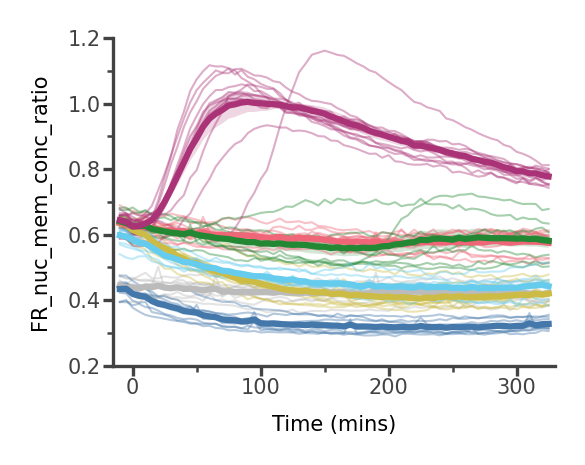

In [142]:
plot_style = {
    'FR_nuc_mem_conc_ratio': {
        'ylim': [0.2, 1.2],
        'yticks': [0.2, 0.4, 0.6, 0.8,1.0 ,1.2],
        'yminorticks': 2,
        'xlim': [-15, 330],
        'xticks': [0, 100, 200, 300,400],
        'xminorticks': 2,
    }
}

conditions = ['231_D', '231_P','235_D', '235_P', '235_MEK', '235_APT','235_TMI']
variables = ['FR_nuc_mem_conc_ratio']

plotter.plot_traces(
    var_names=variables,
    conditions=conditions,
    frame_range=(0, 67),
    figsize=(1.9,1.5),
    errorbar="se",
    style=plot_style,
    file_stem="PMA_traces_FOV",
)

[saved figure] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/plot_exports/PMA_bar_FOV.svg
[saved points] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/plot_exports/PMA_bar_FOV_points.csv
[saved summary] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/plot_exports/PMA_bar_FOV_summary.csv
[saved params] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/plot_exports/PMA_bar_FOV_params.json


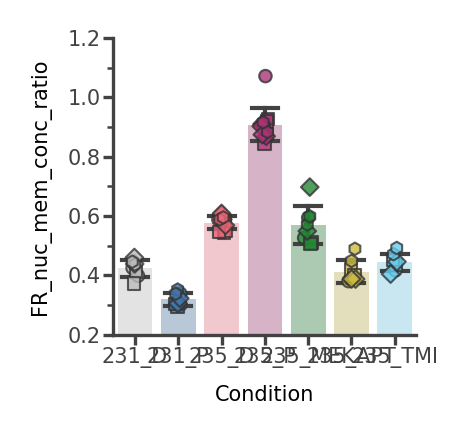

In [109]:
plot_style = {
    'FR_nuc_mem_conc_ratio': {
        'ylim': [0.2, 1.2],
        'yticks': [0.2, 0.4, 0.6, 0.8,1.0 ,1.2],
        'yminorticks': 2,
    }
}

conditions = ['231_D', '231_P','235_D', '235_P', '235_MEK', '235_APT','235_TMI']
variables = ['FR_nuc_mem_conc_ratio']

allpoints = plotter.barplot(
    var_names=variables,
    conditions=conditions,
    frame_range=(31, 51),#21 and 22 corresponds to 95 min and 100 min
    figsize=(1.5,1.4),
    style=plot_style,
     file_stem="PMA_bar_FOV",
)


In [55]:
import numpy as np
from scipy import stats

comps =  [['231_D','231_P'],['231_D','235_D'], ['235_D','235_P'],['235_D', '235_MEK'],['235_D', '235_APT'],['235_D', '235_TMI']]
for one, two in comps:
    first=allpoints['FR_nuc_mem_conc_ratio'][allpoints['FR_nuc_mem_conc_ratio']['condition']==one]['value_mean']
    second=allpoints['FR_nuc_mem_conc_ratio'][allpoints['FR_nuc_mem_conc_ratio']['condition']==two]['value_mean']

    tstat, pval = stats.ttest_ind(first, second, equal_var=False)
    mean1, mean2 = first.mean(), second.mean()
    print(
    f"{one} vs {two}: "
    f"mean={mean1:.3f} vs {mean2:.3f}, "
    f"t = {tstat:.2f}, p = {pval:.3g}"
    )

231_D vs 231_P: mean=0.424 vs 0.320, t = 8.34, p = 1.4e-06
231_D vs 235_D: mean=0.424 vs 0.578, t = -12.89, p = 1.1e-08
235_D vs 235_P: mean=0.578 vs 0.909, t = -18.71, p = 1.71e-11
235_D vs 235_MEK: mean=0.578 vs 0.569, t = 0.36, p = 0.73
235_D vs 235_APT: mean=0.578 vs 0.413, t = 10.92, p = 5.77e-07
235_D vs 235_TMI: mean=0.578 vs 0.444, t = 11.17, p = 6.01e-08


[saved figure] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/plot_exports/PMA_comp_bar_FOV.svg
[saved points] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/plot_exports/PMA_comp_bar_FOV_points.csv
[saved summary] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/plot_exports/PMA_comp_bar_FOV_summary.csv
[saved params] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/plot_exports/PMA_comp_bar_FOV_params.json


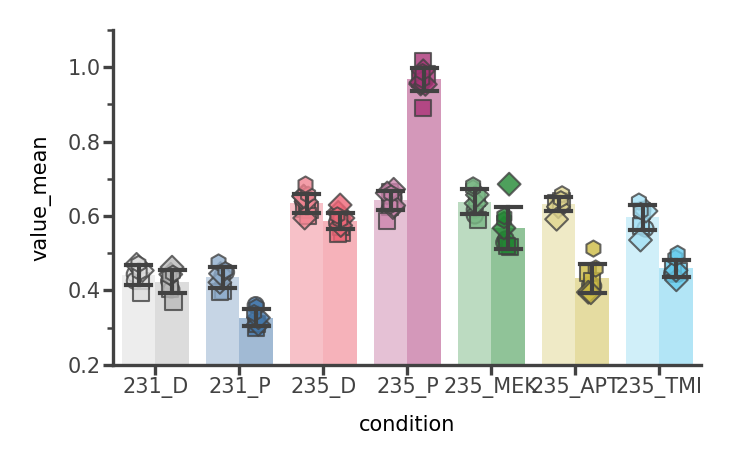

In [155]:
plot_style = {
    'FR_nuc_mem_conc_ratio': {
        'ylim': [0.2, 1.1],
        'yticks': [0.2, 0.4, 0.6, 0.8,1.0 ,1.2],
        'yminorticks': 2,
    }
}

conditions = ['231_D', '231_P','235_D', '235_P', '235_MEK', '235_APT','235_TMI']
variables = ['FR_nuc_mem_conc_ratio']

allpoints = plotter.time_comp_barplot(
    var_names=variables,
    conditions=conditions,
        frame_bins = {"early": (0, 1), "late": (17, 42)}, #corresponds -10/-5 75-200 min
    figsize=(2.4,1.5),
    style=plot_style,
    file_stem="PMA_comp_bar_FOV",
)


[saved figure] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/plot_exports/PMA_deltabar_FOV.svg
[saved points] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/plot_exports/PMA_deltabar_FOV_points.csv
[saved summary] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/plot_exports/PMA_deltabar_FOV_summary.csv
[saved params] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/plot_exports/PMA_deltabar_FOV_params.json


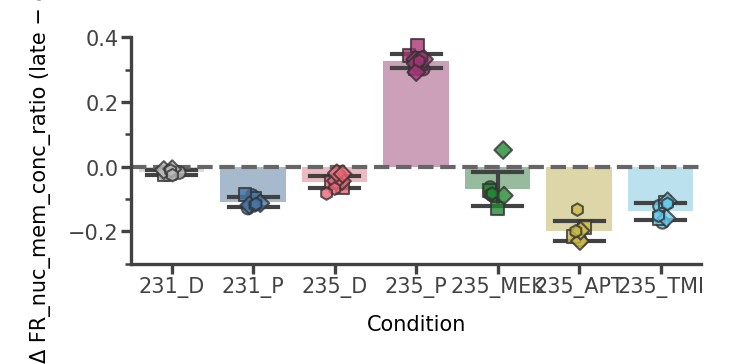

In [156]:
plot_style = {
    'FR_nuc_mem_conc_ratio': {
        'ylim': [-0.3, 0.4],
        'yticks': [-0.2,0, 0.2, 0.4],
        'yminorticks': 2,
    }
}

conditions = ['231_D', '231_P','235_D', '235_P', '235_MEK', '235_APT','235_TMI']
variables = ['FR_nuc_mem_conc_ratio']

allpoints = plotter.delta_barplot(
    var_names=variables,
    conditions=conditions,
    frame_bins = {"early": (0, 1), "late": (17, 42)}, #corresponds -10/-5 75-200 min
    figsize=(2.4,1.166),
    style=plot_style,
    file_stem="PMA_deltabar_FOV",
    normalize_to_pre=False,
)

In [157]:
df = plotter.print_time()
#list(df["time"])[0:2]  # if (0,2) is exclusive of 2
list(df["time"])[17:43]

[75,
 80,
 85,
 90,
 95,
 100,
 105,
 110,
 115,
 120,
 125,
 130,
 135,
 140,
 145,
 150,
 155,
 160,
 165,
 170,
 175,
 180,
 185,
 190,
 195,
 200]

In [158]:
import numpy as np
from scipy import stats

comps =  [['231_D','231_P'],['231_D','235_D'], ['231_P','235_P'],['235_D', '235_P'],['235_D', '235_MEK'],['235_D', '235_APT'],['235_D', '235_TMI']]
for one, two in comps:
    first=allpoints['FR_nuc_mem_conc_ratio'][allpoints['FR_nuc_mem_conc_ratio']['condition']==one]['value_mean']
    second=allpoints['FR_nuc_mem_conc_ratio'][allpoints['FR_nuc_mem_conc_ratio']['condition']==two]['value_mean']

    tstat, pval = stats.ttest_ind(first, second, equal_var=False)
    mean1, mean2 = first.mean(), second.mean()
    print(
    f"{one} vs {two}: "
    f"mean={mean1:.3f} vs {mean2:.3f}, "
    f"t = {tstat:.2f}, p = {pval:.3g}"
    )

231_D vs 231_P: mean=-0.018 vs -0.108, t = 14.96, p = 4.72e-08
231_D vs 235_D: mean=-0.018 vs -0.047, t = 5.16, p = 0.000105
231_P vs 235_P: mean=-0.108 vs 0.326, t = -51.73, p = 6.44e-21
235_D vs 235_P: mean=-0.047 vs 0.326, t = -45.79, p = 1.34e-22
235_D vs 235_MEK: mean=-0.047 vs -0.070, t = 1.18, p = 0.271
235_D vs 235_APT: mean=-0.047 vs -0.200, t = 12.67, p = 1.54e-07
235_D vs 235_TMI: mean=-0.047 vs -0.137, t = 8.44, p = 3.4e-06


[saved figure] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/plot_exports/PMA_traces_FRnuconly_FOV.svg
[saved points] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/plot_exports/PMA_traces_FRnuconly_FOV_points.csv
[saved summary] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/plot_exports/PMA_traces_FRnuconly_FOV_summary.csv
[saved params] /fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/plot_exports/PMA_traces_FRnuconly_FOV_params.json


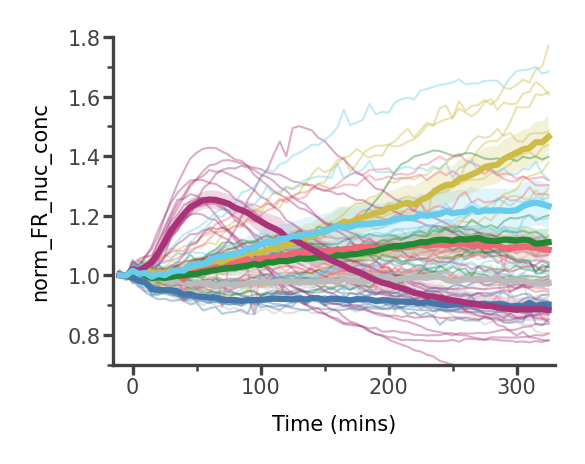

In [163]:
plot_style = {
    'norm_FR_nuc_conc': {
        'ylim': [0.7, 1.8],
        #'yticks': [0.2, 0.4, 0.6, 0.8,1.0 ,1.2],
        'yminorticks': 2,
        'xlim': [-15, 330],
        'xticks': [0, 100, 200, 300,400],
        'xminorticks': 2,
    }
}

conditions = ['231_D', '231_P','235_D', '235_P', '235_MEK', '235_APT','235_TMI']
variables = ['norm_FR_nuc_conc']

plotter.plot_traces(
    var_names=variables,
    conditions=conditions,
    frame_range=(0, 67),
    figsize=(1.9,1.5),
    errorbar="se",
    style=plot_style,
    file_stem="PMA_traces_FRnuconly_FOV",
)